# EV-Szenario: Ladeinfrastruktur Edeka-Parkplatz

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandapower as pp
import itertools
import json

## 1. Daten laden

In [2]:
KABEL_PATH  = "data/netz_excels/kabel_excel.xlsx"
KNOTEN_PATH = "data/netz_excels/knoten_excel.xlsx"
PARAMS_PATH = "data/netz_excels/kabel_parameter.csv"
LASTEN_PATH = "data/gebaudelasten/gebauedelasten.json"
FFE_PATH    = "data/e_ladelasten/ladevorgaenge_200.json"

kabel  = pd.read_excel(KABEL_PATH,  index_col=0)
knoten = pd.read_excel(KNOTEN_PATH, index_col=0)
params = pd.read_csv(PARAMS_PATH)

datetime_index = pd.date_range(start="2018-01-01", end="2018-12-31 23:00", freq="h")
with open(LASTEN_PATH, "r") as f:
    load_df = pd.DataFrame(json.load(f), index=datetime_index)

# FFE-Ladevorgaenge: pu-Profile laden (internal_id[2] == 10)
with open(FFE_PATH) as f:
    rohdaten = json.load(f)

ladevorgaenge_pu = []
for lv in rohdaten:
    for e in lv["data"]:
        if e["internal_id"][2] == 10:
            ladevorgaenge_pu.append(np.array(e["values"]))

print(f"Knoten: {len(knoten)}, Kabel: {len(kabel)}, Zeitschritte: {len(load_df)}")
print(f"FFE-Ladevorgaenge mit pu-Profil: {len(ladevorgaenge_pu)}")

Knoten: 41, Kabel: 45, Zeitschritte: 8760
FFE-Ladevorgaenge mit pu-Profil: 200


## 2. Netz aufbauen

In [3]:
net = pp.create_empty_network(f_hz=50, sn_mva=10)

# Buses
for idx, row in knoten.iterrows():
    pp.create_bus(net, vn_kv=0.4, name=row["IDENTNUMME"], index=idx)

# Slack-Bus (Netzstation)
slack_idx = knoten[knoten["KNOTENTYP"] == "NETZSTATION"].index[0]
pp.create_ext_grid(net, bus=slack_idx, vm_pu=1.0, name=knoten.loc[slack_idx, "IDENTNUMME"])

# Kabelparameter
params_dict = {
    (row["kabeltyp"], row["adern"], row["querschnitt_mm2"]): (
        row["r_ohm_per_km"], row["x_ohm_per_km"], row["c_nf_per_km"], row["max_i_ka"]
    )
    for _, row in params.iterrows()
}

# Leitungen
for idx, row in kabel.iterrows():
    key = (row["KABELTYP"], row["ADERN"], row["QUERSCHNIT"])
    if key not in params_dict:
        continue
    r, x, c, imax = params_dict[key]
    pp.create_line_from_parameters(
        net,
        from_bus=row["start_bus"], to_bus=row["end_bus"],
        length_km=row["length_m"] / 1000,
        r_ohm_per_km=r, x_ohm_per_km=x, c_nf_per_km=c, max_i_ka=imax,
        name=f"Kabel_{idx}"
    )

# Gebaeudelasten
for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    pp.create_load(net, bus=bus_idx, p_mw=load_df.iloc[0][col]/1000, q_mvar=0.0, name=f"Last_{bus_idx}")

# Parkplatz-Bus und Zuleitung
bus_parkplatz = pp.create_bus(net, vn_kv=0.4, name="Parkplatz_Edeka")
r, x, c, imax = params_dict[("NAYY", 4, 150)]
pp.create_line_from_parameters(
    net,
    from_bus=1, to_bus=bus_parkplatz,
    length_km=0.020,
    r_ohm_per_km=r, x_ohm_per_km=x, c_nf_per_km=c, max_i_ka=imax,
    name="Kabel_Parkplatz"
)
pp.create_load(net, bus=bus_parkplatz, p_mw=0.0, q_mvar=0.0, name="EV_Parkplatz")

leitung_parkplatz = net.line[net.line["name"] == "Kabel_Parkplatz"].index[0]

print(f"Buses: {len(net.bus)}, Leitungen: {len(net.line)}, Lasten: {len(net.load)}")
print(f"Parkplatz-Bus: {bus_parkplatz}, Parkplatz-Leitung: {leitung_parkplatz}")

Buses: 42, Leitungen: 46, Lasten: 16
Parkplatz-Bus: 45, Parkplatz-Leitung: 45


## 3. Stochastische EV-Lastprofil-Funktion

In [4]:
def erstelle_ev_lastprofil(n_saeulen, g, ladeleistung_kw, ladevorgaenge_pu, datetime_index, seed=42):
    """
    Stochastisches EV-Lastprofil fuer ein Jahr (8760 h).
    - Anzahl Ankuenfte pro Tag: Poisson(lambda = n_saeulen * g), gedeckelt auf n_saeulen
    - Ankunftszeit: gleichverteilt 8-19 Uhr
    - Ladeprofil: gesampelt aus echten FFE-pu-Profilen (5-Min), auf Stunden gemittelt
    - Ladeleistung: ladeleistung_kw * pu_wert pro Stunde
    Returns: pd.Series mit stuendlicher Last in MW
    """
    rng = np.random.default_rng(seed)
    ev_last_mw = np.zeros(len(datetime_index))
    tage = pd.date_range("2018-01-01", "2018-12-31", freq="D")

    for tag in tage:
        n_ankuenfte = min(rng.poisson(lam=n_saeulen * g), n_saeulen)

        for _ in range(n_ankuenfte):
            ankunft_h = rng.integers(8, 20)

            # Zufaelliges pu-Profil sampeln
            pu_profil = ladevorgaenge_pu[rng.integers(0, len(ladevorgaenge_pu))]

            # 5-Minuten-Werte auf Stunden aggregieren (12 Werte pro Stunde)
            n_stunden = max(1, int(np.ceil(len(pu_profil) / 12)))
            for h in range(n_stunden):
                start     = h * 12
                ende      = min(start + 12, len(pu_profil))
                pu_stunde = np.mean(pu_profil[start:ende])

                ts = tag + pd.Timedelta(hours=ankunft_h + h)
                if ts in datetime_index:
                    ev_last_mw[datetime_index.get_loc(ts)] += (pu_stunde * ladeleistung_kw) / 1000

    return pd.Series(ev_last_mw, index=datetime_index)

## 4. Haushaltsspitzenlastfall bestimmen

In [5]:
haushaltslast_gesamt = load_df.sum(axis=1)  # kW
t_peak = haushaltslast_gesamt.idxmax()

print(f"Spitzenlast-Zeitpunkt: {t_peak}")
print(f"Gesamtlast Haushalte:  {haushaltslast_gesamt[t_peak]:.1f} kW")

# Haushaltslast einmalig setzen — bleibt fuer alle Szenarien gleich
for col in load_df.columns:
    bus_idx = int(col.split("_")[1])
    net.load.loc[net.load["bus"] == bus_idx, "p_mw"] = load_df.loc[t_peak, col] / 1000

Spitzenlast-Zeitpunkt: 2018-11-16 21:00:00
Gesamtlast Haushalte:  167.4 kW


## 5. Szenarienmatrix
- n_saeulen: 10, 20, 30, 40, 50
- g: 0.1, 0.25, 0.5, 0.8
- Ladeleistung: 3.7 kW, 11 kW
- EV-Spitzenlast: stochastisch aus FFE pu-Profilen (seed=42)

In [6]:
n_saeulen_liste = [10, 20, 30, 40, 50]
g_liste         = [0.1, 0.25, 0.5, 0.8]
ladeleistungen  = [3.7, 11.0]

ergebnisse = []

for n_saeulen, g, ladeleistung in itertools.product(n_saeulen_liste, g_liste, ladeleistungen):

    # Stochastisches EV-Profil — Jahresspitzenwert als worst case
    ev_last = erstelle_ev_lastprofil(
        n_saeulen=n_saeulen, g=g, ladeleistung_kw=ladeleistung,
        ladevorgaenge_pu=ladevorgaenge_pu,
        datetime_index=datetime_index, seed=42
    )
    p_ev_peak_mw = ev_last.max()

    # EV-Spitzenlast ins Netz
    net.load.loc[net.load["name"] == "EV_Parkplatz", "p_mw"] = p_ev_peak_mw

    # Lastfluss
    pp.runpp(net, algorithm="nr", numba=False)

    ergebnisse.append({
        "n_saeulen"       : n_saeulen,
        "g"               : g,
        "ladeleistung_kw" : ladeleistung,
        "p_ev_kw"         : p_ev_peak_mw * 1000,
        "vm_min_pu"       : net.res_bus["vm_pu"].min(),
        "loading_max_pct" : net.res_line["loading_percent"].max(),
        "loading_pk_pct"  : net.res_line.loc[leitung_parkplatz, "loading_percent"],
        "leitung_ok"      : net.res_line["loading_percent"].max() <= 100.0,
        "spannung_ok"     : net.res_bus["vm_pu"].min() >= 0.95,
    })

    print(f"✅ {n_saeulen:2d} Saeulen, g={g}, {ladeleistung:4.1f} kW → "
          f"EV-Peak: {p_ev_peak_mw*1000:6.2f} kW, "
          f"Loading: {net.res_line['loading_percent'].max():5.1f}%, "
          f"Vm_min: {net.res_bus['vm_pu'].min():.4f} pu")

matrix_df = pd.DataFrame(ergebnisse)
print("\nFertig!")

✅ 10 Saeulen, g=0.1,  3.7 kW → EV-Peak:  10.86 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 10 Saeulen, g=0.1, 11.0 kW → EV-Peak:  32.28 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 10 Saeulen, g=0.25,  3.7 kW → EV-Peak:  12.90 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 10 Saeulen, g=0.25, 11.0 kW → EV-Peak:  38.36 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 10 Saeulen, g=0.5,  3.7 kW → EV-Peak:  18.08 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 10 Saeulen, g=0.5, 11.0 kW → EV-Peak:  53.76 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 10 Saeulen, g=0.8,  3.7 kW → EV-Peak:  26.00 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 10 Saeulen, g=0.8, 11.0 kW → EV-Peak:  77.30 kW, Loading:  31.1%, Vm_min: 0.9904 pu
✅ 20 Saeulen, g=0.1,  3.7 kW → EV-Peak:  11.05 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 20 Saeulen, g=0.1, 11.0 kW → EV-Peak:  32.84 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 20 Saeulen, g=0.25,  3.7 kW → EV-Peak:  21.76 kW, Loading:  27.5%, Vm_min: 0.9904 pu
✅ 20 Saeulen, g=0.25, 11.0 kW → EV-Peak:  64.69 kW,

## 6. Auswertung — Heatmap Leitungsauslastung

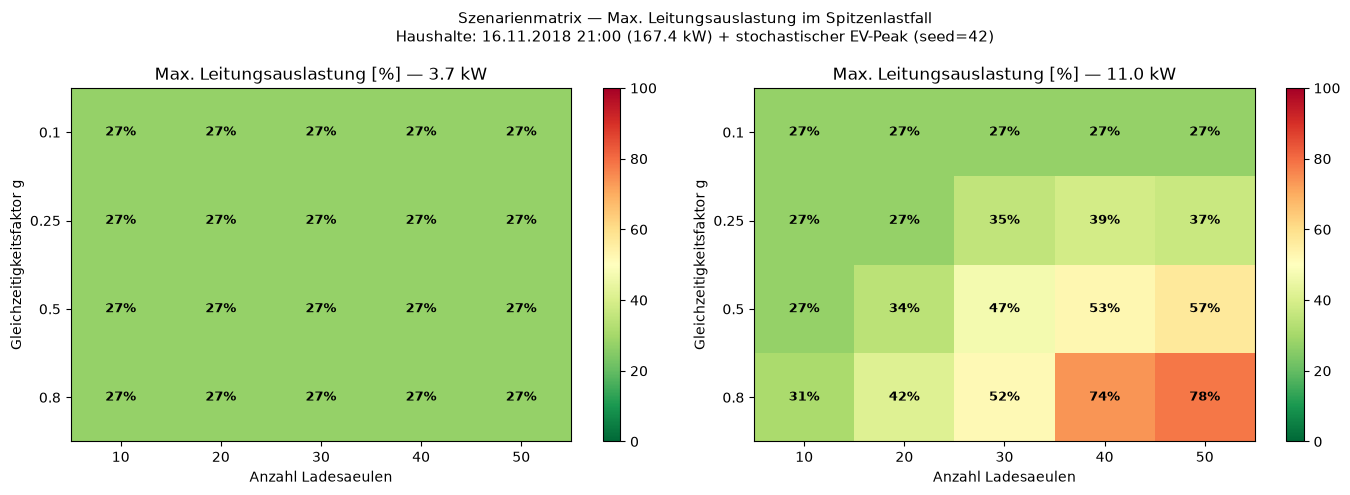

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, lp in zip(axes, [3.7, 11.0]):
    sub   = matrix_df[matrix_df["ladeleistung_kw"] == lp]
    pivot = sub.pivot(index="g", columns="n_saeulen", values="loading_max_pct")

    im = ax.imshow(pivot.values, cmap="RdYlGn_r", vmin=0, vmax=100, aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("Anzahl Ladesaeulen")
    ax.set_ylabel("Gleichzeitigkeitsfaktor g")
    ax.set_title(f"Max. Leitungsauslastung [%] — {lp} kW")

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            ax.text(j, i, f"{pivot.values[i,j]:.0f}%",
                    ha="center", va="center", fontsize=9, fontweight="bold")

    plt.colorbar(im, ax=ax)

plt.suptitle(
    f"Szenarienmatrix — Max. Leitungsauslastung im Spitzenlastfall\n"
    f"Haushalte: {t_peak.strftime('%d.%m.%Y %H:%M')} ({haushaltslast_gesamt[t_peak]:.1f} kW) + stochastischer EV-Peak (seed=42)",
    fontsize=11
)
plt.tight_layout()
plt.show()

## 7. Auswertung — Maximale Ladesaeulenanzahl ohne Grenzwertverletzung

In [8]:
print("Maximale Ladesaeulen ohne Grenzwertverletzung (Leitungsauslastung < 100%):")
print()
for lp in ladeleistungen:
    print(f"--- {lp} kW ---")
    for g in g_liste:
        sub    = matrix_df[(matrix_df["ladeleistung_kw"] == lp) & (matrix_df["g"] == g)]
        ok     = sub[sub["leitung_ok"] == True]
        max_ok = ok["n_saeulen"].max() if len(ok) > 0 else 0
        print(f"  g={g}: max. {max_ok} Ladesaeulen")
    print()

Maximale Ladesaeulen ohne Grenzwertverletzung (Leitungsauslastung < 100%):

--- 3.7 kW ---
  g=0.1: max. 50 Ladesaeulen
  g=0.25: max. 50 Ladesaeulen
  g=0.5: max. 50 Ladesaeulen
  g=0.8: max. 50 Ladesaeulen

--- 11.0 kW ---
  g=0.1: max. 50 Ladesaeulen
  g=0.25: max. 50 Ladesaeulen
  g=0.5: max. 50 Ladesaeulen
  g=0.8: max. 50 Ladesaeulen



In [9]:
# Szenario: 50 Säulen, g=0.8, 11 kW
n_saeulen    = 50
g            = 0.8
ladeleistung = 11.0

# Stochastisches EV-Profil für das gesamte Jahr
ev_last_jahr = erstelle_ev_lastprofil(
    n_saeulen=n_saeulen, g=g, ladeleistung_kw=ladeleistung,
    ladevorgaenge_pu=ladevorgaenge_pu,
    datetime_index=datetime_index, seed=42
)

res_vm   = {}
res_load = {}

for i, (ts, row) in enumerate(load_df.iterrows()):
    # Haushaltslast
    for col in load_df.columns:
        bus_idx = int(col.split("_")[1])
        net.load.loc[net.load["bus"] == bus_idx, "p_mw"] = row[col] / 1000

    # EV-Last
    net.load.loc[net.load["name"] == "EV_Parkplatz", "p_mw"] = ev_last_jahr.iloc[i]

    pp.runpp(net, algorithm="nr", numba=False)

    res_vm[ts]   = net.res_bus["vm_pu"].copy()
    res_load[ts] = net.res_line["loading_percent"].copy()

vm_pu_df   = pd.DataFrame.from_dict(res_vm,   orient="index")
loading_df = pd.DataFrame.from_dict(res_load, orient="index")

print(f"Max. Leitungsauslastung: {loading_df.max().max():.1f}%")
print(f"Min. Busspannung:        {vm_pu_df.min().min():.4f} pu")
print(f"Peak EV-Last:            {ev_last_jahr.max()*1000:.1f} kW")

Max. Leitungsauslastung: 78.3%
Min. Busspannung:        0.9902 pu
Peak EV-Last:            194.3 kW


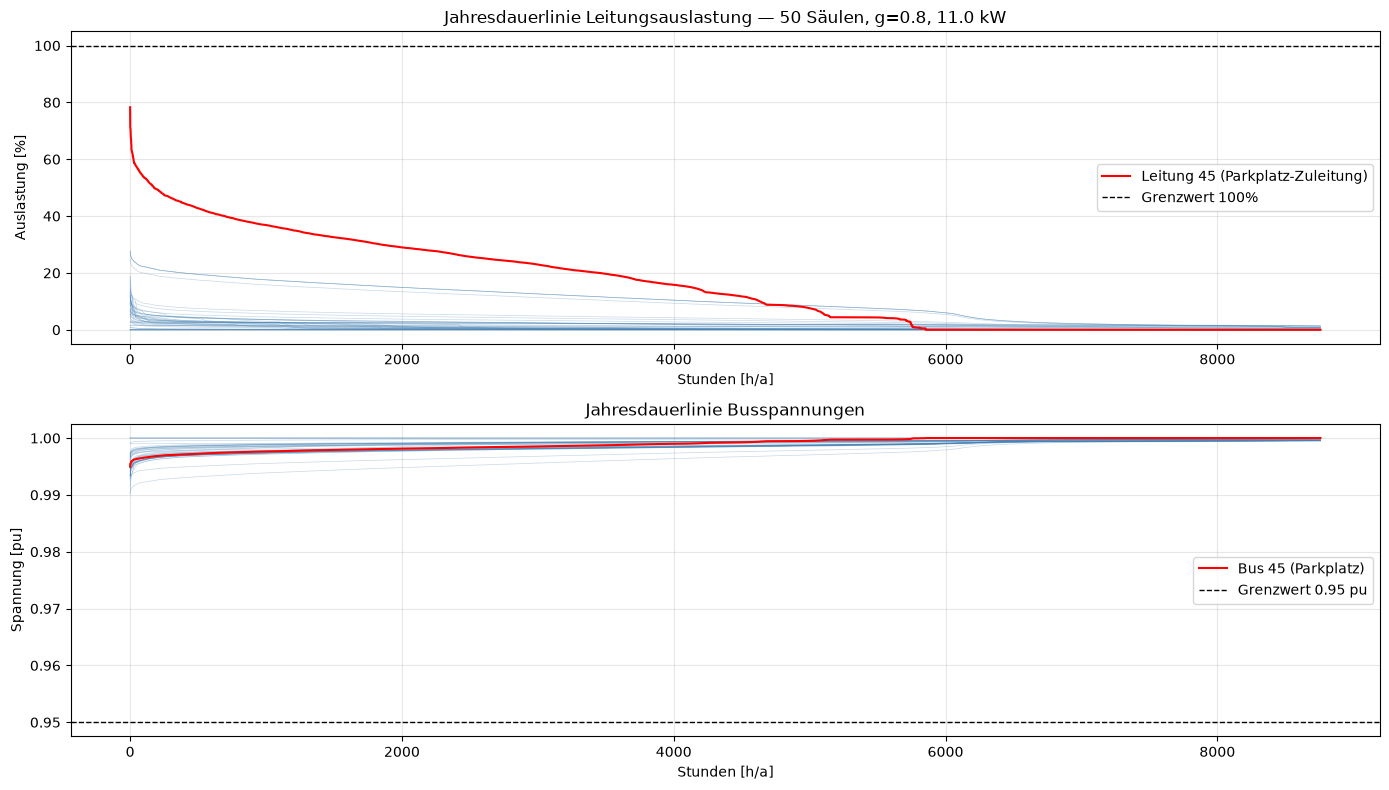

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Alle Leitungen
for col in loading_df.columns:
    sortiert = loading_df[col].sort_values(ascending=False).values
    axes[0].plot(range(8760), sortiert, color="steelblue", linewidth=0.5, alpha=0.3)

# Parkplatz-Leitung hervorheben
axes[0].plot(range(8760), loading_df[leitung_parkplatz].sort_values(ascending=False).values,
             color="red", linewidth=1.5, label=f"Leitung {leitung_parkplatz} (Parkplatz-Zuleitung)")
axes[0].axhline(100, color="black", linestyle="--", linewidth=1.0, label="Grenzwert 100%")
axes[0].set_xlabel("Stunden [h/a]")
axes[0].set_ylabel("Auslastung [%]")
axes[0].set_title(f"Jahresdauerlinie Leitungsauslastung — {n_saeulen} Säulen, g={g}, {ladeleistung} kW")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Alle Busse
for col in vm_pu_df.columns:
    sortiert = vm_pu_df[col].sort_values(ascending=True).values
    axes[1].plot(range(8760), sortiert, color="steelblue", linewidth=0.5, alpha=0.3)

# Parkplatz-Bus hervorheben
axes[1].plot(range(8760), vm_pu_df[bus_parkplatz].sort_values(ascending=True).values,
             color="red", linewidth=1.5, label=f"Bus {bus_parkplatz} (Parkplatz)")
axes[1].axhline(0.95, color="black", linestyle="--", linewidth=1.0, label="Grenzwert 0.95 pu")
axes[1].set_xlabel("Stunden [h/a]")
axes[1].set_ylabel("Spannung [pu]")
axes[1].set_title("Jahresdauerlinie Busspannungen")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()